# 🎬 Sentiment Analysis on Movie Reviews Practicle

In this practicle, you will create ML models that predict sentiments on the  **IMDb movie reviews dataset**. To complete this task, you will be asked to complete the following sections:

1. Installing and importing libraries
2. Loading and exploring the dataset
3. Text preprocessing
4. Feature extraction (TF-IDF)
5. Training multiple classifiers
6. Evaluating model performance
7. Visualising results
8. Predicting sentiment on new reviews

---

## Step 1 — Install Required Libraries

Install the following libraries that will help you work on the dataset:

A library for removing punctuation, numbers, or extra spaces from text (`re` — built into Python, no install needed)

A WordNet resource that groups words according to their meanings and relationships (`nltk`, specifically the WordNet corpus)

A library for loading/reading the data into a CSV (`pandas`)

A library for plotting a confusion matrix (`matplotlib`)

Install numpy version 1.26.4 (`numpy==1.26.4`)

An NLP library for tokenization, stopword removal, and lemmatization (`nltk`)

A library for machine learning classification that will use three models: logistic regression, multinomial Naive Bayes, and Support Vector Machine (SVM), and provide evaluation results, a classification report, and a confusion matrix (`scikit-learn`)

Download NLTK resources for stopwords, punkt_tab (`nltk.download(...)`)


In [ ]:
!pip install --upgrade nltk scikit-learn pandas numpy==1.26.4 matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2


## Step 2 — Download the Dataset from kagglehub

Download the IMDB Dataset of 50K Movie Reviews using [Kagglehub](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews):

Once downloaded, print the path of the downloaded file

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


## Step 3 — Load and inspect the data head.

Load the data into a csv and print out the first 5 lines.

In [ ]:
import pandas as pd

movie_reviews = "/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
df = pd.read_csv(movie_reviews)
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Step 4 — Text Preprocessing

Perform core NLP text preprocessing techniques on the "review" text column, such as tokenization, stopword removal, noise removal, lowercasing, and lemmatization, and then print out the original reviews with the cleaned reviews. Name the column with the clean reviews'clean_review'.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download the NLTK resources needed for stopword removal, tokenisation, and lemmatisation
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

#WordNetLemmatizer is an NLTK tool that reduces words to their base/dictionary form (e.g. "running" → "run", "movies" → "movie")
#stopwords.words('english') is a built-in NLTK list of ~180 common words like "the", "is", "and" that carry little meaning — wrapping it in set() makes lookups faster

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() #Converts everything to lowercase so "Brilliant" and "brilliant" are treated as the same word.
    text = re.sub(r'<.*?>', '', text)       # Removes any HTML tags (e.g. <br />) that are common in scraped web data like IMDb reviews.
    text = re.sub(r'[^a-z0-9\s]', '', text)    # Strips out anything that isn't a letter or whitespace, but keeps digits — so punctuation, and special characters are all removed.
    tokens = word_tokenize(text) #Splits the cleaned string into a list of individual word tokens using NLTK's tokeniser
    tokens = [  #store everything in a list.
        lemmatizer.lemmatize(tok)
        for tok in tokens  #This loops through every token (word) in the original tokens list.
        if tok not in stop_words and len(tok) > 2  #This is a filter. Only tokens satisfying both conditions are kept.Keeps only words longer than two characters.
    ]
    return ' '.join(tokens)  #joins the cleaned tokens back into a single string, since the TF-IDF vectoriser in the next step expects a string, not a list.

df['clean_review'] = df['review'].apply(preprocess_text) #Runs every review through the function and saves the result in a new column.

print('Original :', df['review'].iloc[0]) #Give me the review at position 0 (the first row).
print('Cleaned  :', df['clean_review'].iloc[0]) #Give me the review at position 0 (the first row).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Original : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

## Step 5 — TF-IDF Feature Extraction & split data into train and test set

Split the data into testing and training using the [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function and apply [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) on your features 'clean_review'.

Next, print out the number of features in the training sample, test samples, and vocubulary size.  You can choose max_features to be 10k in your TF-IDF vectoriser.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df['clean_review']
y = df['sentiment']


#Split into training and test sets. 25% of data should be held back for testing, while 75% used for training
#use stratify=y to ensure that positive/negative ratio is preserved in both splits. Without this, you could end up with, say, 90% positive reviews in training by chance, which would bias the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


tfidf = TfidfVectorizer(  #Set up the TF-IDF vectoriser
    max_features=10_000,  #build a vocabulary that only consider the top max_features ordered by term frequency across the corpus. Otherwise, all features are used.

)

X_train_tfidf = tfidf.fit_transform(X_train)  #.fit_transform(X_train) — learns the vocabulary and IDF weights from the training data only, then transforms it
X_test_tfidf  = tfidf.transform(X_test) #.transform(X_test) — applies the same vocabulary learned from training to the test set, without learning anything new
#Fitting on the test set too would be data leakage — the model would have indirect knowledge of test data before evaluation, giving falsely optimistic results.

print(f'Training samples : {X_train_tfidf.shape[0]}')
print(f'Test samples     : {X_test_tfidf.shape[0]}')
print(f'Vocabulary size  : {X_train_tfidf.shape[1]:,}')


Training samples : 37500
Test samples     : 12500
Vocabulary size  : 10,000


## Step 6 — Train Multiple Models

Train three ML classifiers (logistic regression, Naive Bayes, and linear SVM) that will detect sentiment in your extracted features. Print out the accuracies of each model and select/print out the best model with its accuracy.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

#Define the three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000, random_state=42),
}
#Train each model and collect results
results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'predictions': y_pred, 'accuracy': acc}
    print(f'{name:<25}  Accuracy: {acc:.4f}') #f = display as a floating-point number., .4 = show 4 digits after the decimal point., 25 → reserve 25 character spaces.

#Find the best model
best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model: {best_name} ({results[best_name]["accuracy"]:.4f})')


Logistic Regression        Accuracy: 0.8942
Naive Bayes                Accuracy: 0.8682
Linear SVM                 Accuracy: 0.8846

Best model: Logistic Regression (0.8942)


## Question, what is the best performing model?

## Step 7 — Classification report & Confusion matrix

Print out the Classification report & Confusion matrix of the best model

Classification Report -- Logistic Regression

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      6250
    Positive       0.89      0.90      0.90      6250

    accuracy                           0.89     12500
   macro avg       0.89      0.89      0.89     12500
weighted avg       0.89      0.89      0.89     12500



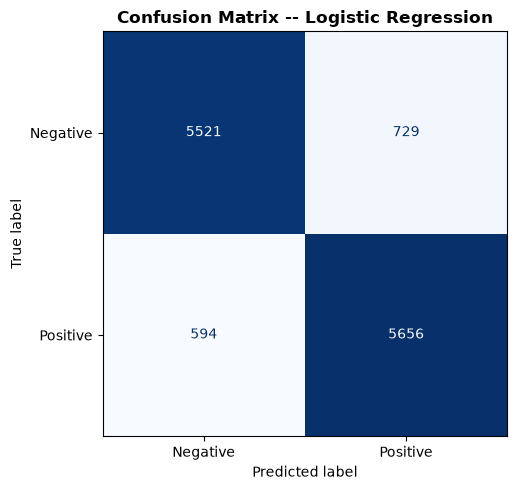

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#print out the classification report and confusion matrix
best_preds = results[best_name]['predictions']

## Print the heading showing the name of the best-performing model.
print(f'Classification Report -- {best_name}\n')
print(classification_report(y_test, best_preds, target_names=['Negative', 'Positive'])) ## Display precision, recall, F1-score, and support for each class.

cm = confusion_matrix(y_test, best_preds) # Compute the confusion matrix using the true and predicted labels.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive']) ## Create a ConfusionMatrixDisplay object for visualizing the confusion matrix.

fig, ax = plt.subplots(figsize=(6, 5)) # Create a new figure and axes with a specified size.
disp.plot(ax=ax, cmap='Blues', colorbar=False) # Plot the confusion matrix using a blue color map without a color bar. A color bar is a legend that explains what the colors in a plot represent
ax.set_title(f'Confusion Matrix -- {best_name}', fontweight='bold') ## Add a bold title to the confusion matrix plot.
plt.tight_layout() # Adjust the layout to prevent labels and titles from overlapping.
plt.show() # Display the confusion matrix plot.


## Step 8 — Top Predictive Features

Use a horizontal bar chat to display the 15 most important positive and gegative features learned by the logistic regression model

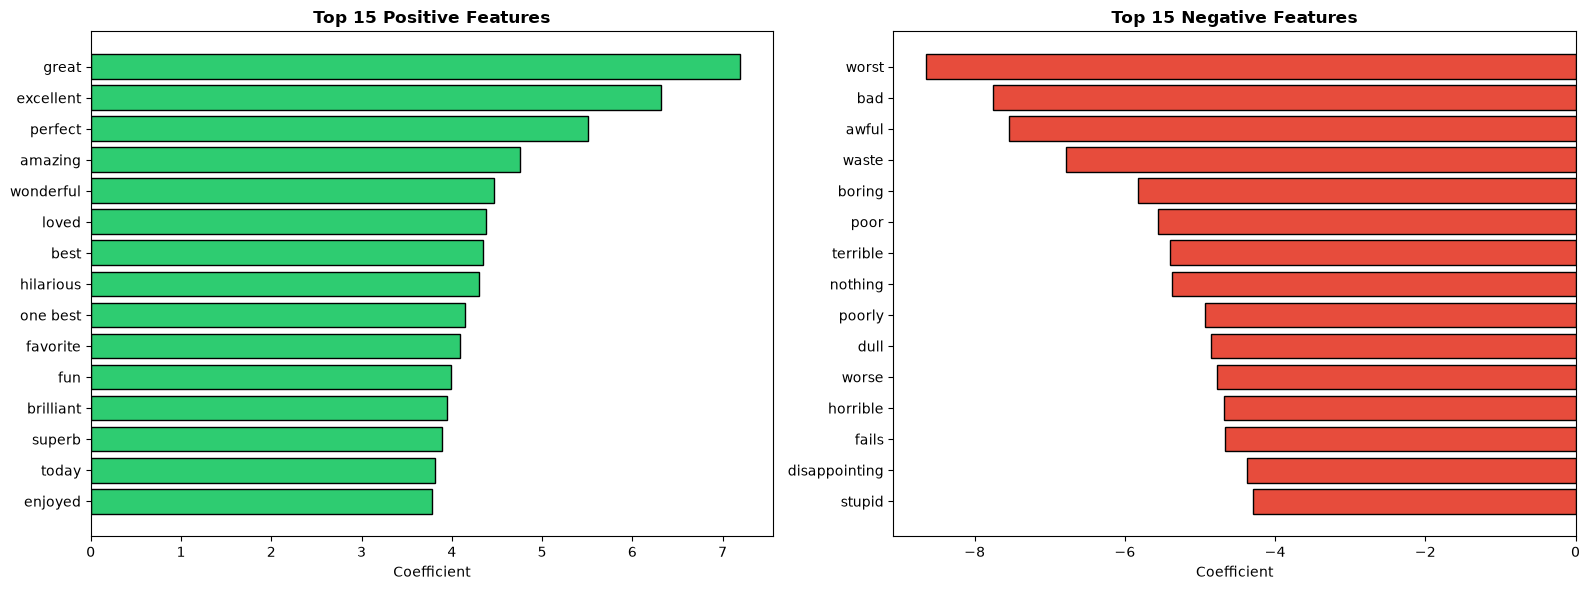

In [ ]:
import numpy as np

#Extract the logistic regression coefficients. Logistic regression coefficients tells us how much each feature influences the model's prediction.
lr_model      = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out()) #gives you the actual words
coefs         = lr_model.coef_[0] #is an array of the same length — one coefficient per feature
top_n         = 15


top_pos = np.argsort(coefs)[-top_n:][::-1] # Get the indices of the top_n largest (most positive) coefficients in descending order
top_neg = np.argsort(coefs)[:top_n] # Get the indices of the top_n smallest (most negative) coefficients.

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Create a figure with two subplots arranged side by side.

#Draw the horizontal bar charts. barh = horizontal bar chart

axes[0].barh(feature_names[top_pos], coefs[top_pos], color='#2ecc71', edgecolor='black') # Plot the top positive features and their coefficients.
axes[0].set_title('Top 15 Positive Features', fontweight='bold') ## Add a title to the positive features plot.
axes[0].set_xlabel('Coefficient') # Label the x-axis with the coefficient values.
axes[0].invert_yaxis() #Reverse the y-axis so the most important feature appears at the top.

axes[1].barh(feature_names[top_neg], coefs[top_neg], color='#e74c3c', edgecolor='black') #Add a title to the negative features plot.
axes[1].set_title('Top 15 Negative Features', fontweight='bold')  #Add a title to the negative features plot.
axes[1].set_xlabel('Coefficient') #Label the x-axis with the coefficient values.
axes[1].invert_yaxis() ## Reverse the y-axis so the most important feature appears at the top.

plt.tight_layout() #Adjust the spacing between the subplots to prevent overlap.
plt.show() # Display the figure containing both bar charts.


## Step 9 — Predict Sentiment on New Reviews

Predict sentiment on the three new reviews below using the best model:

new_reviews = [
    "This movie was an absolute masterpiece. Blown away by the performances.",
    "Terrible. The plot was confusing and the acting was wooden. Complete waste of money.",
    "It was okay. Some good moments but overall a bit disappointing.",
]


In [ ]:
#Write a function that predicts sentiments on new movie reviews
#Write code here

def predict_sentiment(review_text, model_name='Logistic Regression'):

    # Preprocess the input review using the same steps applied to the training data.
    #Write code here
    cleaned = preprocess_text(review_text)

    # Convert the cleaned review into TF-IDF features.
    #Write code here
    features = tfidf.transform([cleaned])

    # Use the selected trained model to predict the sentiment.
    #Write code here
    pred = results[model_name]['model'].predict(features)[0]

    # Convert the numeric prediction into a human-readable label.
    #Write code here
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'

    # Display only the first 110 characters of long reviews.
    #Write code here
    snippet = review_text[:110] + '...' if len(review_text) > 110 else review_text

    # Print the review snippet.
    #Write code here
    print(f'Review  : {snippet}')

    # Print the name of the model used for prediction.
    #Write code here
    print(f'Model   : {model_name}')

    # Print the predicted sentiment.
    #Write code here
    print(f'Verdict : {label}')

    # Print a separator line between predictions.
    #Write code here
    print('-' * 70)   # Repeats '-' 70 times.


# Define a list of new reviews to classify.
new_reviews = [
    "This movie was an absolute masterpiece. Blown away by the performances.",
    "Terrible. The plot was confusing and the acting was wooden. Complete waste of money.",
    "It was okay. Some good moments but overall a bit disappointing.",
]

# Run the sentiment prediction function on each new review.
for review in new_reviews:
    predict_sentiment(review)

Review  : This movie was an absolute masterpiece. Blown away by the performances.
Model   : Logistic Regression
Verdict : NEGATIVE
----------------------------------------------------------------------
Review  : Terrible. The plot was confusing and the acting was wooden. Complete waste of money.
Model   : Logistic Regression
Verdict : NEGATIVE
----------------------------------------------------------------------
Review  : It was okay. Some good moments but overall a bit disappointing.
Model   : Logistic Regression
Verdict : NEGATIVE
----------------------------------------------------------------------
